In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ Libraries imported successfully!")
print("📊 Ready for environmental impact analysis")


✅ Libraries imported successfully!
📊 Ready for environmental impact analysis


In [2]:
# Load operational gasification data
print("🔬 Loading operational gasification data...")
operational_df = pd.read_csv('data/gasification_data_refined.csv')

print(f"✅ Operational data loaded: {operational_df.shape}")
print(f"🔍 Technologies: {operational_df['technology'].unique()}")
print(f"🔍 Key parameters available:")
print(f"   - Temperature: {operational_df['temperature_C'].min():.0f}-{operational_df['temperature_C'].max():.0f}°C")
print(f"   - H2 yield: {operational_df['H2_yield_mol_kg'].min():.1f}-{operational_df['H2_yield_mol_kg'].max():.1f} mol/kg")
print(f"   - CO yield: {operational_df['CO_yield_mol_kg'].min():.1f}-{operational_df['CO_yield_mol_kg'].max():.1f} mol/kg")

# Display first few rows
print("\n📋 Sample of operational data:")
operational_df.head()


🔬 Loading operational gasification data...
✅ Operational data loaded: (24, 15)
🔍 Technologies: ['co2' 'steam' 'scw' 'plasma']
🔍 Key parameters available:
   - Temperature: 400-1200°C
   - H2 yield: 1.6-22.5 mol/kg
   - CO yield: 2.1-18.7 mol/kg

📋 Sample of operational data:


,technology,temperature_C,reaction_time_min,pressure_bar,feedstock_type,agent_ratio,H2_yield_mol_kg,CO_yield_mol_kg,CO2_yield_mol_kg,CH4_yield_mol_kg,carbon_efficiency_pct,energy_input_kW,reactor_type,study_reference,notes
0,co2,700.0,30.0,80.0,biomass,NaN,7.89,5.98,NaN,NaN,47.26,NaN,supercritical,this_study_700C,supercritical_CO2_conditions
1,co2,750.0,30.0,80.0,biomass,NaN,9.37,7.05,NaN,NaN,60.32,NaN,supercritical,this_study_750C,supercritical_CO2_conditions
2,co2,800.0,30.0,80.0,biomass,NaN,13.56,8.34,NaN,NaN,71.18,NaN,supercritical,this_study_800C,supercritical_CO2_conditions
3,co2,850.0,30.0,80.0,biomass,NaN,5.13,12.45,NaN,NaN,86.57,NaN,supercritical,this_study_850C,supercritical_CO2_conditions
4,co2,900.0,30.0,80.0,biomass,NaN,16.85,17.65,NaN,NaN,94.53,NaN,supercritical,this_study_900C,supercritical_CO2_conditions


In [3]:
# Load environmental impact data (LCA results)
print("🌍 Loading environmental impact target data...")
lca_df = pd.read_excel('data/LCA/LCAResultsWithWaste.xlsx')
lca_df.columns = [col.strip() for col in lca_df.columns]

# Rename technology columns to match operational data
column_mapping = {
    'CO2 Gasfication': 'co2',
    'Plasma Gasification': 'plasma', 
    'SCWG': 'scw',
    'Steam Gasification': 'steam'
}
lca_df = lca_df.rename(columns=column_mapping)

print(f"✅ Environmental impact data loaded: {lca_df.shape}")
print(f"🔍 Impact categories: {lca_df.shape[0]}")
print(f"🔍 Technologies: {[col for col in lca_df.columns if col != 'Impact categories']}")

# Display the environmental impact data
print("\n🌍 Environmental Impact Categories:")
lca_df


🌍 Loading environmental impact target data...
✅ Environmental impact data loaded: (18, 6)
🔍 Impact categories: 18
🔍 Technologies: ['Unit', 'co2', 'plasma', 'scw', 'steam']

🌍 Environmental Impact Categories:


,Impact categories,Unit,co2,plasma,scw,steam
0,agricultural land occupation,m2*a,5.865880e-05,2.710380e-05,1.598440e-05,4.032200e-05
1,climate change,kg CO2-Eq,1.979730e+00,1.043810e+00,8.844300e-01,1.698390e+00
2,fossil depletion,kg oil-Eq,3.650300e-01,2.432400e-01,1.553400e-01,4.458600e-01
3,freshwater ecotoxicity,"kg 1,4-DCB-Eq",4.851000e-02,1.373000e-02,1.232000e-02,6.176000e-02
4,freshwater eutrophication,kg P-Eq,5.300000e-04,5.900000e-04,4.500000e-04,9.900000e-04
5,human toxicity,"kg 1,4-DCB-Eq",4.790500e-01,4.064100e-01,2.982200e-01,6.963500e-01
6,ionising radiation,kg U235-Eq,1.280900e-01,2.145100e-01,1.839300e-01,3.892200e-01
7,marine ecotoxicity,"kg 1,4-DCB-Eq",4.230000e-02,1.187000e-02,1.051000e-02,5.299000e-02
8,marine eutrophication,kg N-Eq,1.260000e-03,6.600000e-04,3.500000e-04,9.400000e-04
9,metal depletion,kg Fe-Eq,4.200000e-04,7.100000e-04,6.100000e-04,1.270000e-03


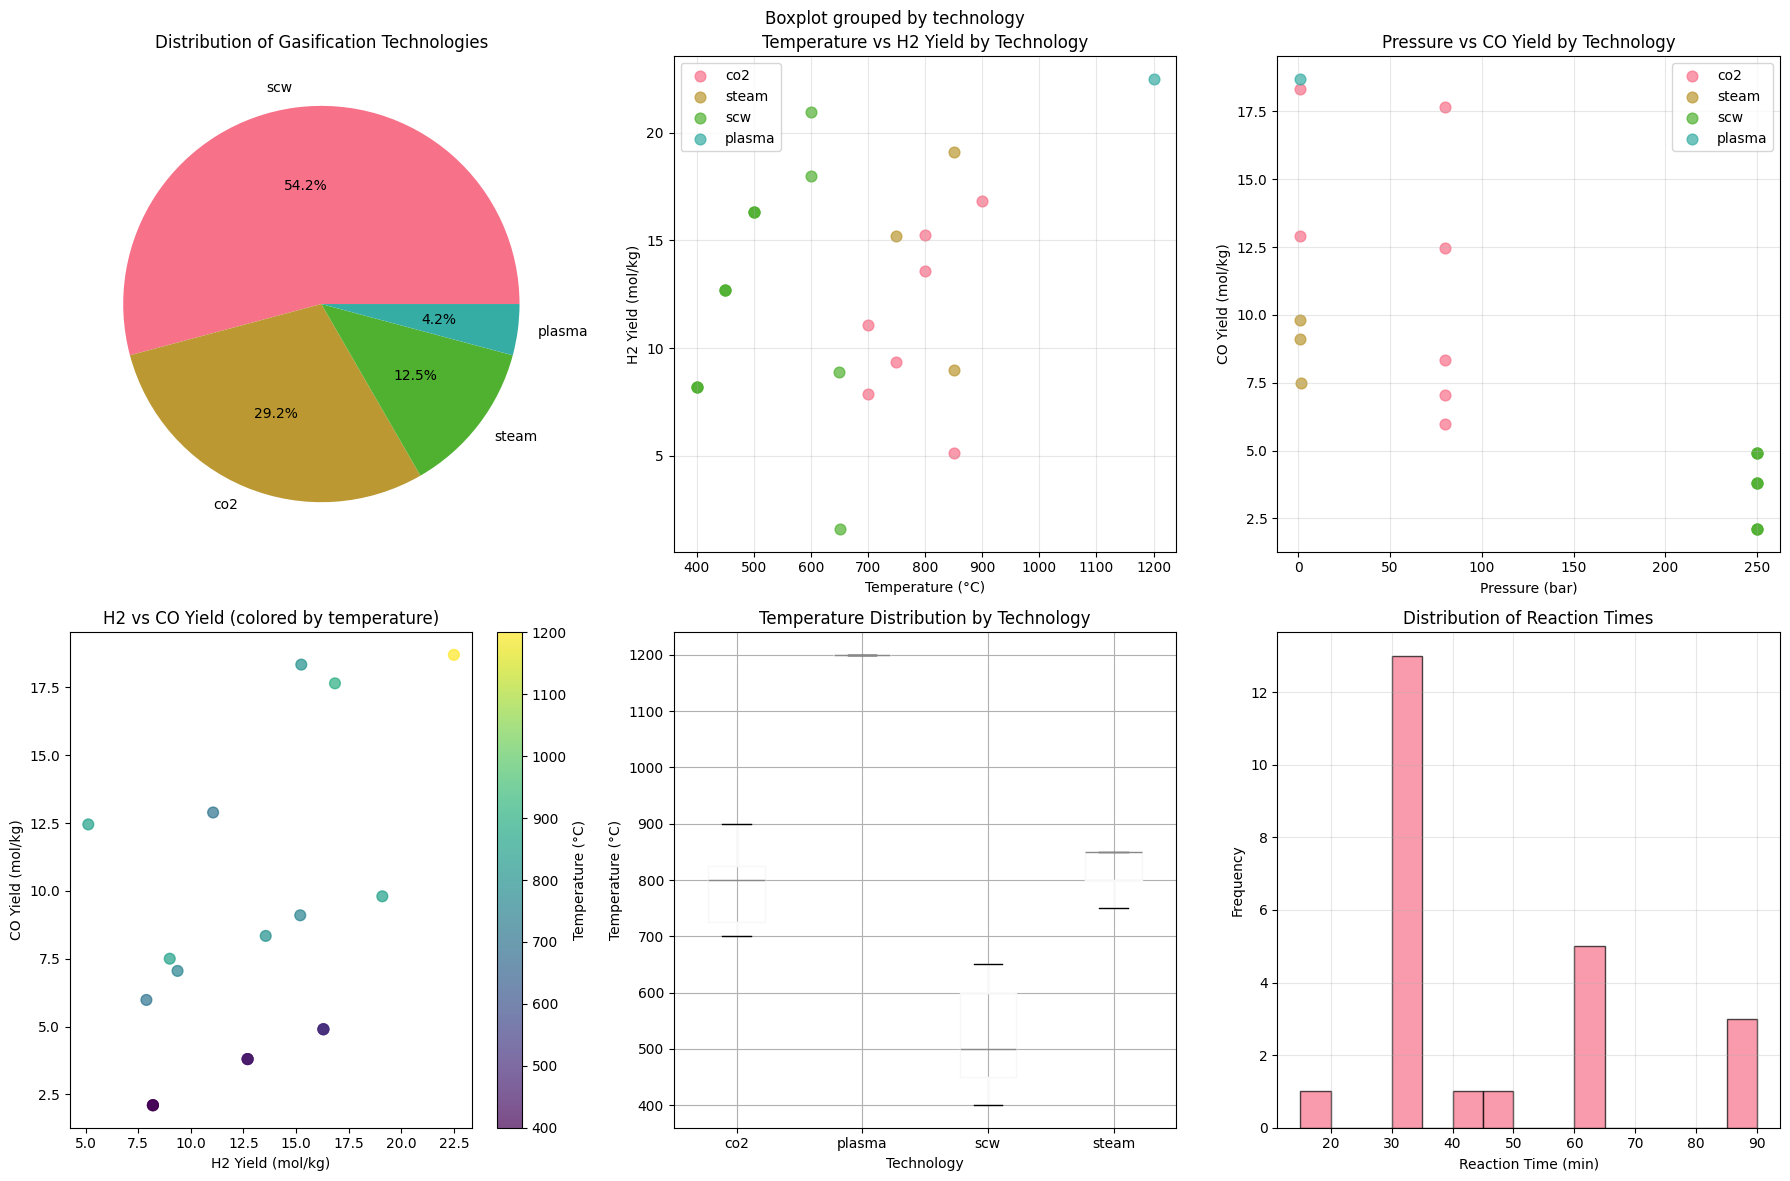


📊 Summary Statistics by Technology:


temperature_C                 pressure_bar                \
                    mean     min     max         mean    min    max   
technology                                                            
co2                785.7   700.0   900.0         57.4    1.0   80.0   
plasma            1200.0  1200.0  1200.0          1.0    1.0    1.0   
scw                503.9   400.0   651.0        245.4  210.0  250.0   
steam              816.7   750.0   850.0          1.2    1.0    1.6   

           H2_yield_mol_kg             CO_yield_mol_kg              
                      mean   min   max            mean   min   max  
technology                                                          
co2                   11.3   5.1  16.8            11.8   6.0  18.3  
plasma                22.5  22.5  22.5            18.7  18.7  18.7  
scw                   12.4   1.6  21.0             3.6   2.1   4.9  
steam                 14.4   9.0  19.1             8.8   7.5   9.8

In [4]:
# Create exploratory visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Technology distribution
axes[0, 0].pie(operational_df['technology'].value_counts().values, 
               labels=operational_df['technology'].value_counts().index, 
               autopct='%1.1f%%')
axes[0, 0].set_title('Distribution of Gasification Technologies')

# 2. Temperature vs H2 yield by technology
for tech in operational_df['technology'].unique():
    data = operational_df[operational_df['technology'] == tech]
    axes[0, 1].scatter(data['temperature_C'], data['H2_yield_mol_kg'], 
                      label=tech, alpha=0.7, s=60)
axes[0, 1].set_xlabel('Temperature (°C)')
axes[0, 1].set_ylabel('H2 Yield (mol/kg)')
axes[0, 1].set_title('Temperature vs H2 Yield by Technology')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Pressure vs CO yield by technology
for tech in operational_df['technology'].unique():
    data = operational_df[operational_df['technology'] == tech]
    axes[0, 2].scatter(data['pressure_bar'], data['CO_yield_mol_kg'], 
                      label=tech, alpha=0.7, s=60)
axes[0, 2].set_xlabel('Pressure (bar)')
axes[0, 2].set_ylabel('CO Yield (mol/kg)')
axes[0, 2].set_title('Pressure vs CO Yield by Technology')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. H2 vs CO yield relationship
axes[1, 0].scatter(operational_df['H2_yield_mol_kg'], operational_df['CO_yield_mol_kg'], 
                   c=operational_df['temperature_C'], cmap='viridis', alpha=0.7, s=60)
axes[1, 0].set_xlabel('H2 Yield (mol/kg)')
axes[1, 0].set_ylabel('CO Yield (mol/kg)')
axes[1, 0].set_title('H2 vs CO Yield (colored by temperature)')
cbar = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])
cbar.set_label('Temperature (°C)')

# 5. Temperature distribution by technology
operational_df.boxplot(column='temperature_C', by='technology', ax=axes[1, 1])
axes[1, 1].set_title('Temperature Distribution by Technology')
axes[1, 1].set_xlabel('Technology')
axes[1, 1].set_ylabel('Temperature (°C)')

# 6. Reaction time distribution
axes[1, 2].hist(operational_df['reaction_time_min'], bins=15, alpha=0.7, edgecolor='black')
axes[1, 2].set_xlabel('Reaction Time (min)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Distribution of Reaction Times')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n📊 Summary Statistics by Technology:")
summary_stats = operational_df.groupby('technology').agg({
    'temperature_C': ['mean', 'min', 'max'],
    'pressure_bar': ['mean', 'min', 'max'],
    'H2_yield_mol_kg': ['mean', 'min', 'max'],
    'CO_yield_mol_kg': ['mean', 'min', 'max']
}).round(1)

summary_stats


In [5]:
# Create training dataset by mapping operational parameters to environmental impacts
print("🔗 Creating training dataset...")

# Get impact categories list
impact_categories = list(lca_df['Impact categories'])

# Get technology averages from operational data for mapping
tech_averages = operational_df.groupby('technology').agg({
    'temperature_C': 'mean',
    'pressure_bar': 'mean',
    'H2_yield_mol_kg': 'mean',
    'CO_yield_mol_kg': 'mean',
    'reaction_time_min': 'mean'
}).reset_index()

print("🎯 Technology averages:")
print(tech_averages)

# Create training rows - mapping each operational data point to its technology's environmental impacts
training_data = []

for _, op_row in operational_df.iterrows():
    tech = op_row['technology']
    
    if tech in lca_df.columns:
        impacts = lca_df[tech].values
        
        features = {
            'technology': tech,
            'temperature_C': op_row['temperature_C'],
            'pressure_bar': op_row['pressure_bar'],
            'H2_yield_mol_kg': op_row['H2_yield_mol_kg'],
            'CO_yield_mol_kg': op_row['CO_yield_mol_kg'],
            'reaction_time_min': op_row['reaction_time_min']
        }
        
        # Add environmental impact values (same for all points of same technology)
        for i, impact_category in enumerate(impact_categories):
            features[f'impact_{i:02d}_{impact_category.replace(" ", "_").lower()}'] = impacts[i]
        
        training_data.append(features)

training_df = pd.DataFrame(training_data)

print(f"\n✅ Training dataset created: {training_df.shape}")
print(f"🔍 Features: {len([col for col in training_df.columns if not col.startswith('impact_')])}")
print(f"🔍 Target variables (environmental impacts): {len([col for col in training_df.columns if col.startswith('impact_')])}")

# Show sample of training data
print("\n📋 Sample of training dataset (features only):")
feature_cols = [col for col in training_df.columns if not col.startswith('impact_')]
training_df[feature_cols].head()


🔗 Creating training dataset...
🎯 Technology averages:
  technology  temperature_C  pressure_bar  H2_yield_mol_kg  CO_yield_mol_kg  \
0        co2     785.714286     57.428571        11.301429        11.814286   
1     plasma    1200.000000      1.000000        22.500000        18.700000   
2        scw     503.923077    245.384615        12.391538         3.600000   
3      steam     816.666667      1.193333        14.433333         8.800000   

   reaction_time_min  
0          30.000000  
1          15.000000  
2          56.538462  
3          33.333333  

✅ Training dataset created: (24, 24)
🔍 Features: 6
🔍 Target variables (environmental impacts): 18

📋 Sample of training dataset (features only):


,technology,temperature_C,pressure_bar,H2_yield_mol_kg,CO_yield_mol_kg,reaction_time_min
0,co2,700.0,80.0,7.89,5.98,30.0
1,co2,750.0,80.0,9.37,7.05,30.0
2,co2,800.0,80.0,13.56,8.34,30.0
3,co2,850.0,80.0,5.13,12.45,30.0
4,co2,900.0,80.0,16.85,17.65,30.0


🛠️ Preparing features and targets...
✅ Feature matrix: (24, 6)
✅ Target matrix: (24, 18)
🔍 Features: ['temperature_C', 'pressure_bar', 'H2_yield_mol_kg', 'CO_yield_mol_kg', 'reaction_time_min', 'technology_encoded']
🔍 Technology encoding: {'co2': np.int64(0), 'plasma': np.int64(1), 'scw': np.int64(2), 'steam': np.int64(3)}

🔗 Feature Correlation Matrix:


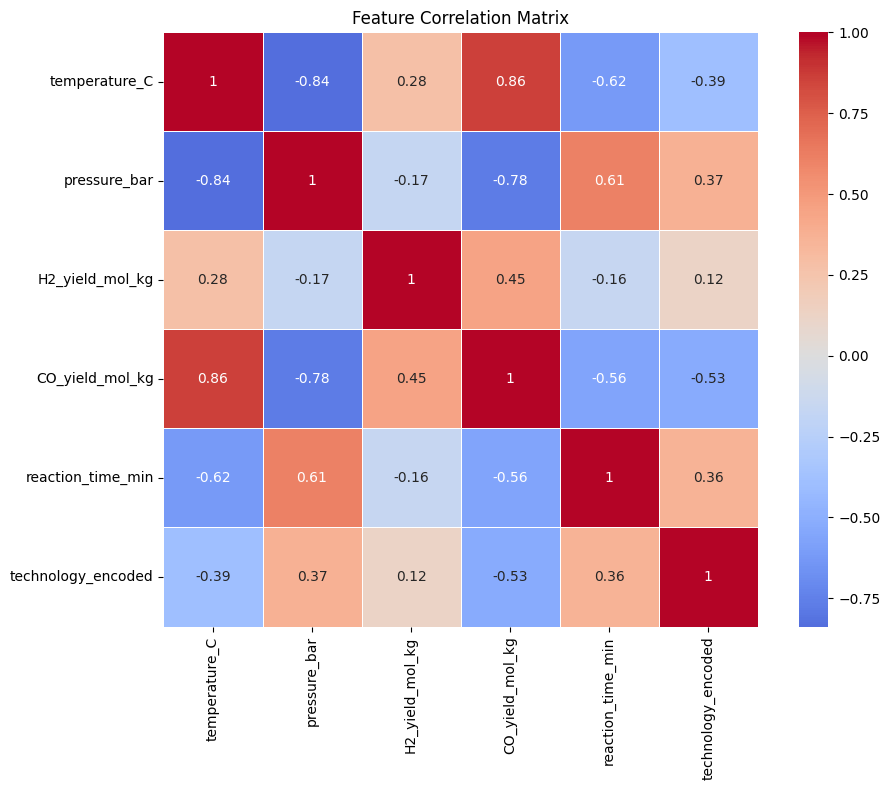

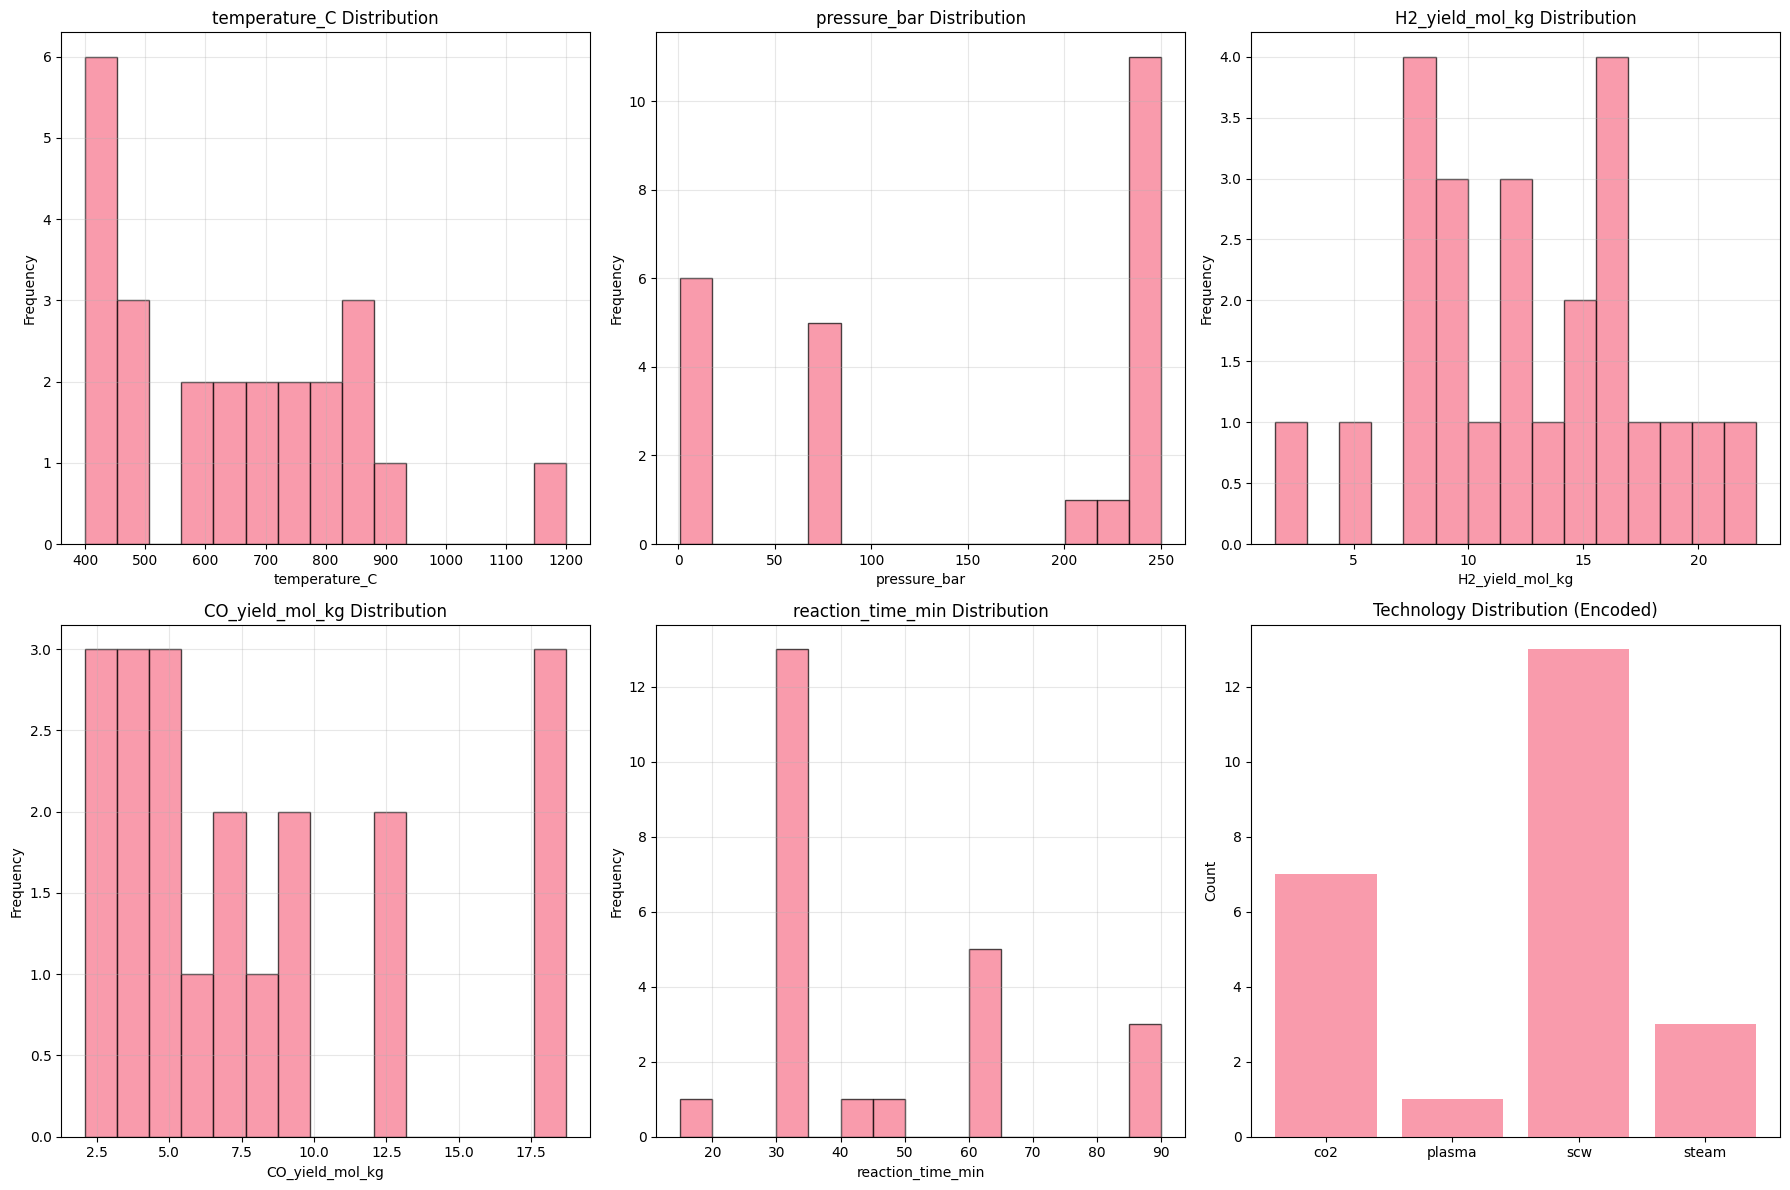

In [6]:
# Prepare features and targets for ML training
print("🛠️ Preparing features and targets...")

# Feature columns (operational parameters)
feature_cols = ['temperature_C', 'pressure_bar', 'H2_yield_mol_kg', 'CO_yield_mol_kg', 'reaction_time_min']

# Technology encoding
le_tech = LabelEncoder()
tech_encoded = le_tech.fit_transform(training_df['technology'])

# Create feature matrix
X = training_df[feature_cols].copy()
X['technology_encoded'] = tech_encoded

# Create target matrix (all environmental impacts)
impact_cols = [col for col in training_df.columns if col.startswith('impact_')]
y = training_df[impact_cols].values

print(f"✅ Feature matrix: {X.shape}")
print(f"✅ Target matrix: {y.shape}")
print(f"🔍 Features: {list(X.columns)}")
print(f"🔍 Technology encoding: {dict(zip(le_tech.classes_, le_tech.transform(le_tech.classes_)))}")

# Display correlation matrix of features
print("\n🔗 Feature Correlation Matrix:")
correlation_matrix = X.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Show feature distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, col in enumerate(feature_cols):
    axes[i].hist(X[col], bins=15, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

# Technology encoding distribution
axes[5].bar(range(len(le_tech.classes_)), 
           [sum(X['technology_encoded'] == i) for i in range(len(le_tech.classes_))],
           alpha=0.7)
axes[5].set_xticks(range(len(le_tech.classes_)))
axes[5].set_xticklabels(le_tech.classes_)
axes[5].set_title('Technology Distribution (Encoded)')
axes[5].set_ylabel('Count')

plt.tight_layout()
plt.show()


In [7]:
# Train environmental impact prediction models
print("🤖 Training environmental impact prediction models...")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handle NaN values by filling with median
imputer = SimpleImputer(strategy='median')
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

print(f"📊 Training set: {X_train_scaled.shape}")
print(f"📊 Test set: {X_test_scaled.shape}")

# Try multiple models
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    'Ridge (Multi-output)': MultiOutputRegressor(Ridge(alpha=1.0))
}

best_model = None
best_score = -np.inf
best_name = ""
results = {}

print("\n🔄 Training and evaluating models...")

for name, model in models.items():
    print(f"\n📊 Training {name}...")
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Evaluate
    r2 = r2_score(y_test, y_pred, multioutput='uniform_average')
    mse = mean_squared_error(y_test, y_pred, multioutput='uniform_average')
    mae = mean_absolute_error(y_test, y_pred, multioutput='uniform_average')
    
    print(f"   ✅ R² Score: {r2:.3f}")
    print(f"   📏 MSE: {mse:.3e}")
    print(f"   📐 MAE: {mae:.3e}")
    
    results[name] = {
        'model': model,
        'r2': r2,
        'mse': mse,
        'mae': mae,
        'predictions': y_pred
    }
    
    if r2 > best_score:
        best_score = r2
        best_model = model
        best_name = name

print(f"\n🏆 Best model: {best_name} (R² = {best_score:.3f})")

# Save the best model
model_data = {
    'model': best_model,
    'scaler': scaler,
    'imputer': imputer,
    'label_encoder': le_tech,
    'impact_categories': impact_categories,
    'feature_names': list(X.columns)
}

joblib.dump(model_data, 'environmental_impact_model.pkl')
print("💾 Best model saved as 'environmental_impact_model.pkl'")


🤖 Training environmental impact prediction models...
📊 Training set: (16, 6)
📊 Test set: (8, 6)

🔄 Training and evaluating models...

📊 Training Random Forest...
   ✅ R² Score: 0.897
   📏 MSE: 4.885e-04
   📐 MAE: 4.328e-03

📊 Training Ridge (Multi-output)...
   ✅ R² Score: 0.934
   📏 MSE: 5.202e-04
   📐 MAE: 7.274e-03

🏆 Best model: Ridge (Multi-output) (R² = 0.934)
💾 Best model saved as 'environmental_impact_model.pkl'


In [8]:
# Analyze model performance for each environmental impact category
print("📈 Analyzing model performance by impact category...")

y_pred = best_model.predict(X_test_scaled)

# Calculate R² for each impact category
impact_r2_scores = []
for i in range(y_test.shape[1]):
    try:
        r2 = r2_score(y_test[:, i], y_pred[:, i])
        # Handle edge cases where all predictions are the same (zero variance)
        if np.isnan(r2):
            r2 = 0.0
        impact_r2_scores.append(r2)
    except:
        impact_r2_scores.append(0.0)

# Create performance DataFrame
performance_df = pd.DataFrame({
    'Impact_Category': impact_categories,
    'R2_Score': impact_r2_scores
}).sort_values('R2_Score', ascending=False)

print("\n🎯 Model Performance by Environmental Impact:")
print("=" * 70)
for _, row in performance_df.iterrows():
    print(f"{row['Impact_Category']:<50} R² = {row['R2_Score']:>7.3f}")

print(f"\n📊 Overall Statistics:")
print(f"   Average R² Score: {np.mean(impact_r2_scores):.3f}")
print(f"   Best R² Score: {np.max(impact_r2_scores):.3f}")
print(f"   Worst R² Score: {np.min(impact_r2_scores):.3f}")
print(f"   Standard Deviation: {np.std(impact_r2_scores):.3f}")

# Show the performance DataFrame
print("\n📋 Complete Performance Results:")
performance_df


📈 Analyzing model performance by impact category...

🎯 Model Performance by Environmental Impact:
natural land transformation                        R² =   0.980
agricultural land occupation                       R² =   0.977
urban land occupation                              R² =   0.977
marine eutrophication                              R² =   0.977
photochemical oxidant formation                    R² =   0.977
terrestrial ecotoxicity                            R² =   0.976
water depletion                                    R² =   0.974
terrestrial acidification                          R² =   0.971
climate change                                     R² =   0.971
fossil depletion                                   R² =   0.958
marine ecotoxicity                                 R² =   0.948
freshwater ecotoxicity                             R² =   0.947
particulate matter formation                       R² =   0.936
human toxicity                                     R² =   0.928
ozone 

,Impact_Category,R2_Score
10,natural land transformation,0.980064
0,agricultural land occupation,0.977471
16,urban land occupation,0.977223
8,marine eutrophication,0.977156
13,photochemical oxidant formation,0.976776
15,terrestrial ecotoxicity,0.975510
17,water depletion,0.974102
14,terrestrial acidification,0.971386
1,climate change,0.970538
2,fossil depletion,0.957865


In [9]:
# Analyze feature importance
print("🔍 Analyzing feature importance...")

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    
    # Create feature importance DataFrame
    importance_df = pd.DataFrame({
        'Feature': list(X.columns),
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("\n🔝 Feature Importances:")
    print("=" * 40)
    for _, row in importance_df.iterrows():
        print(f"{row['Feature']:<25} {row['Importance']:>8.1%}")
    
    # Create feature importance visualization
    plt.figure(figsize=(10, 6))
    bars = plt.barh(range(len(importance_df)), importance_df['Importance'])
    plt.yticks(range(len(importance_df)), importance_df['Feature'])
    plt.xlabel('Feature Importance')
    plt.title('Feature Importance for Environmental Impact Prediction')
    plt.gca().invert_yaxis()
    
    # Color bars
    for i, bar in enumerate(bars):
        if importance_df.iloc[i]['Importance'] > 0.3:
            bar.set_color('darkgreen')
        elif importance_df.iloc[i]['Importance'] > 0.15:
            bar.set_color('green')
        elif importance_df.iloc[i]['Importance'] > 0.05:
            bar.set_color('orange')
        else:
            bar.set_color('red')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Feature Importance Analysis:")
    print(f"   Most important feature: {importance_df.iloc[0]['Feature']} ({importance_df.iloc[0]['Importance']:.1%})")
    print(f"   Least important feature: {importance_df.iloc[-1]['Feature']} ({importance_df.iloc[-1]['Importance']:.1%})")
    
    # Show the importance DataFrame
    importance_df
else:
    print("ℹ️  Feature importance not available for this model type")
    importance_df = None


🔍 Analyzing feature importance...
ℹ️  Feature importance not available for this model type


📊 Creating comprehensive visualizations...


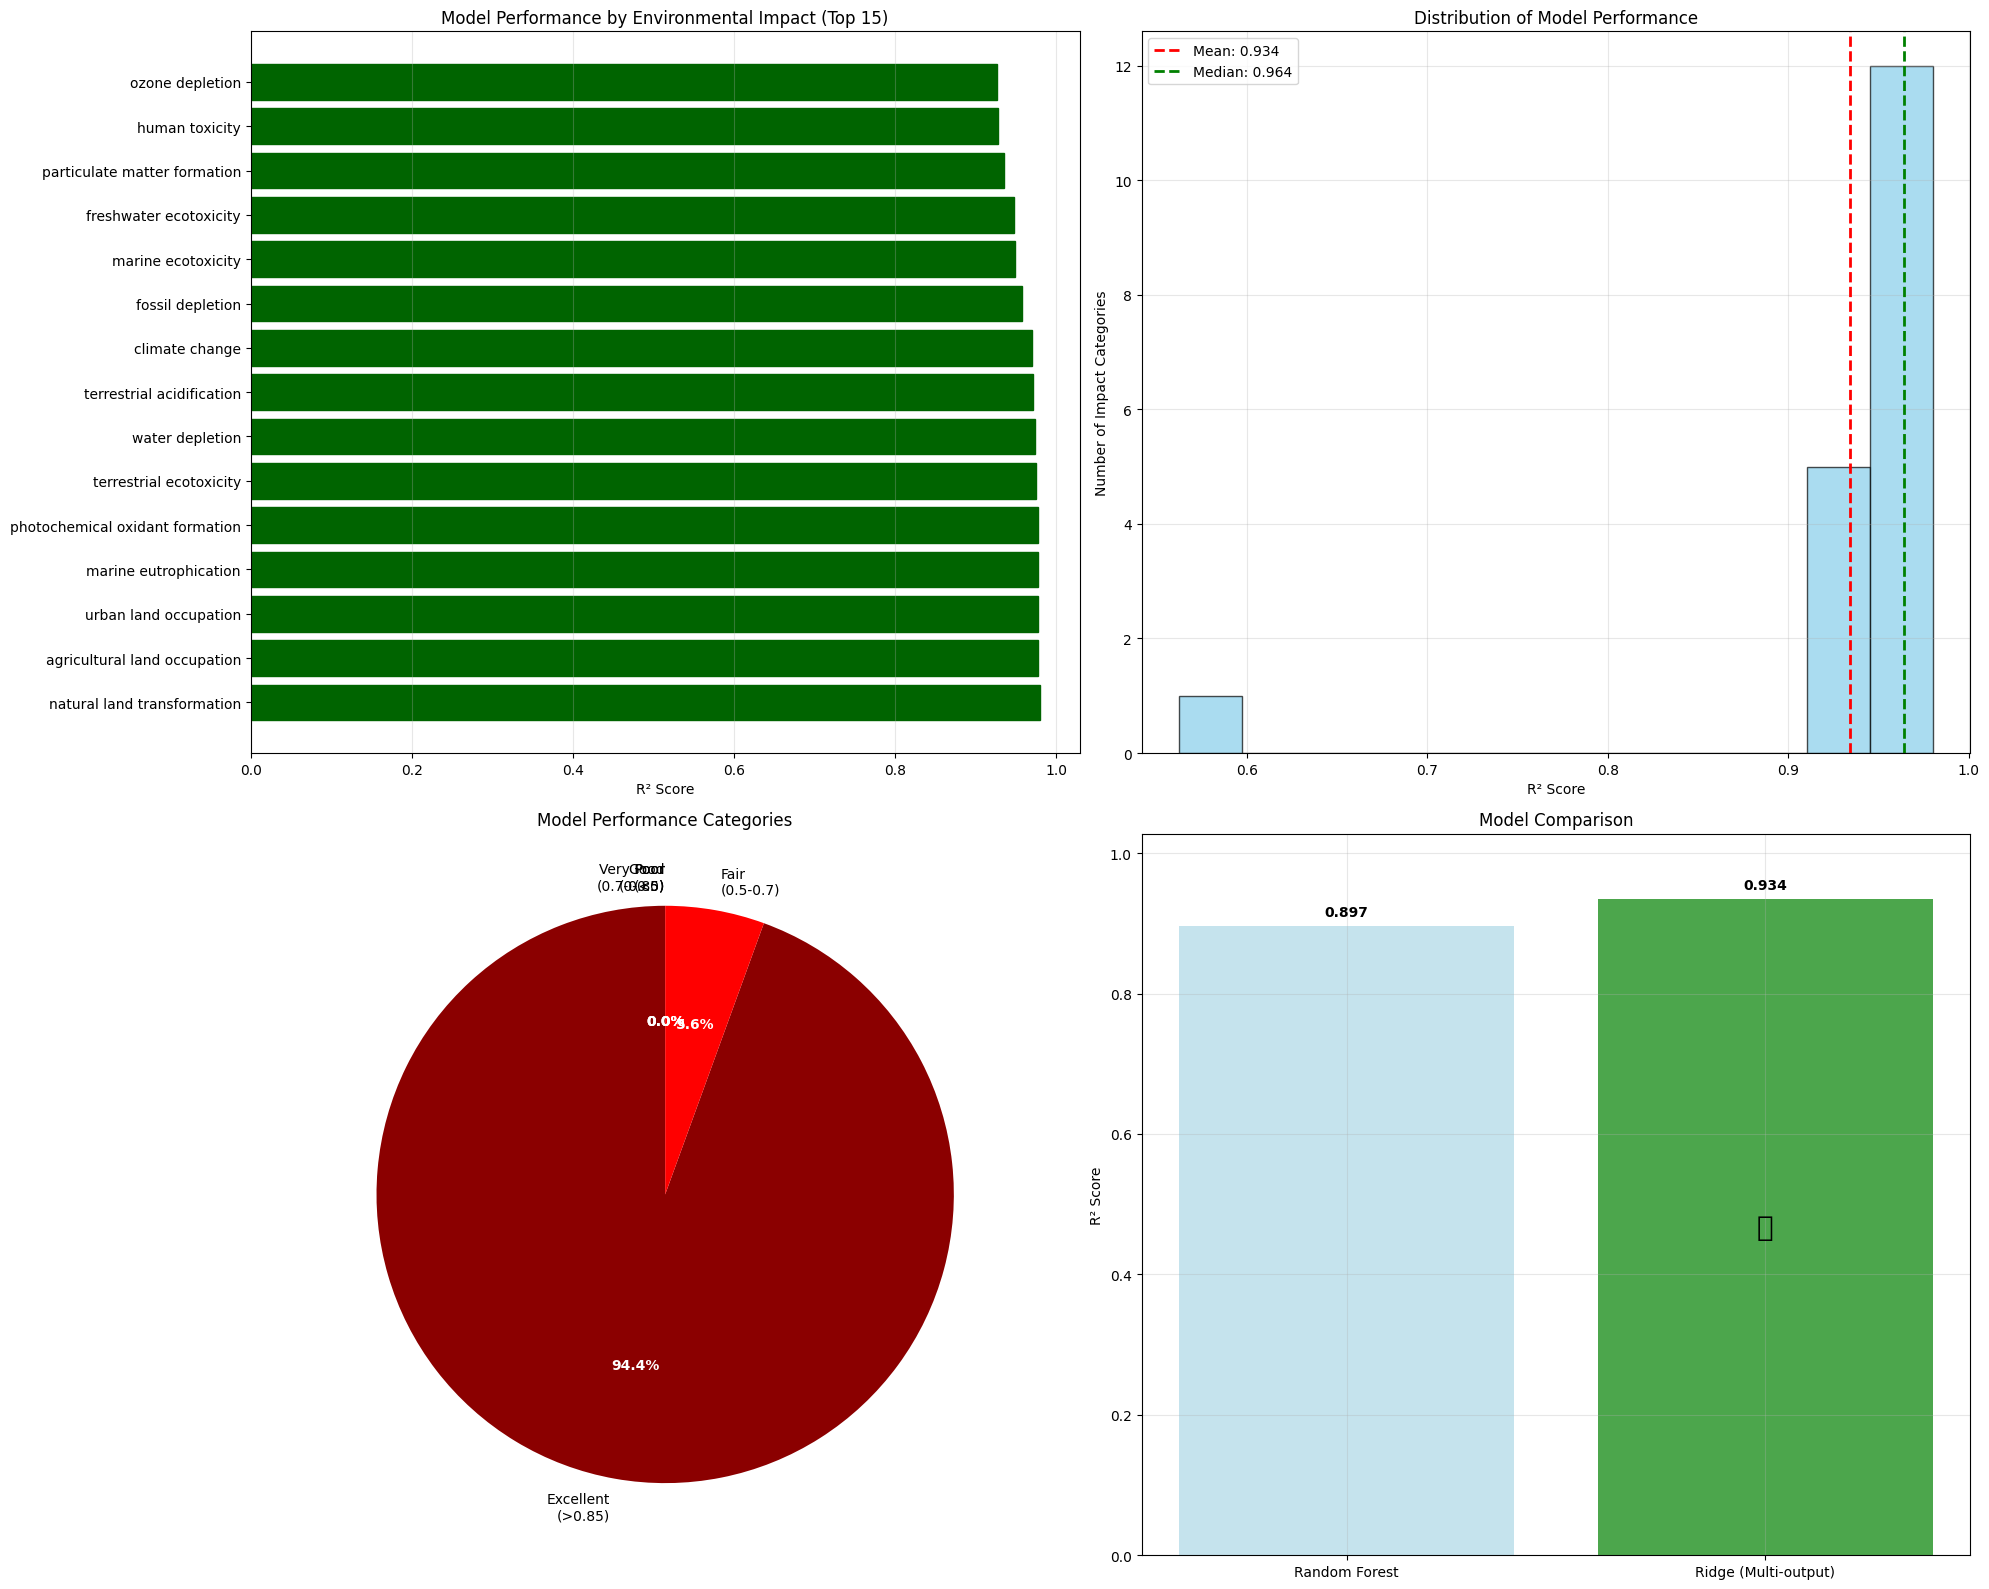

✅ Comprehensive visualizations created and saved as 'environmental_impact_model_analysis.png'

🔍 Detailed Performance Analysis:
📈 Excellent (R² ≥ 0.85): 17 categories (94.4%)
   Best: natural land transformation (R² = 0.980)
📊 Good (0.7 ≤ R² < 0.85): 0 categories (0.0%)
📉 Fair (0.5 ≤ R² < 0.7): 1 categories (5.6%)
❌ Poor (R² < 0.5): 0 categories (0.0%)


In [10]:
# Create comprehensive performance visualizations
print("📊 Creating comprehensive visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Model Performance by Impact Category (Top 15 for readability)
ax1 = axes[0, 0]
performance_df_plot = performance_df.head(15)
bars = ax1.barh(range(len(performance_df_plot)), performance_df_plot['R2_Score'])
ax1.set_yticks(range(len(performance_df_plot)))
ax1.set_yticklabels([cat[:35] + '...' if len(cat) > 35 else cat for cat in performance_df_plot['Impact_Category']])
ax1.set_xlabel('R² Score')
ax1.set_title('Model Performance by Environmental Impact (Top 15)')
ax1.grid(axis='x', alpha=0.3)

# Color bars based on performance
for i, bar in enumerate(bars):
    score = performance_df_plot.iloc[i]['R2_Score']
    if score >= 0.8:
        bar.set_color('darkgreen')
    elif score >= 0.6:
        bar.set_color('green')
    elif score >= 0.3:
        bar.set_color('orange')
    else:
        bar.set_color('red')

# 2. Performance Distribution Histogram
ax2 = axes[0, 1]
ax2.hist(performance_df['R2_Score'], bins=12, alpha=0.7, edgecolor='black', color='skyblue')
ax2.set_xlabel('R² Score')
ax2.set_ylabel('Number of Impact Categories')
ax2.set_title('Distribution of Model Performance')
ax2.axvline(performance_df['R2_Score'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {performance_df["R2_Score"].mean():.3f}')
ax2.axvline(performance_df['R2_Score'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {performance_df["R2_Score"].median():.3f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Performance Categories Pie Chart
ax3 = axes[1, 0]
performance_bins = pd.cut(performance_df['R2_Score'], 
                         bins=[-float('inf'), 0, 0.5, 0.7, 0.85, 1.0], 
                         labels=['Very Poor\n(<0)', 'Poor\n(0-0.5)', 'Fair\n(0.5-0.7)', 'Good\n(0.7-0.85)', 'Excellent\n(>0.85)'])
performance_counts = performance_bins.value_counts().dropna()

if len(performance_counts) > 0:
    colors = ['darkred', 'red', 'orange', 'lightgreen', 'darkgreen'][:len(performance_counts)]
    wedges, texts, autotexts = ax3.pie(performance_counts.values, labels=performance_counts.index, 
                                      autopct='%1.1f%%', colors=colors, startangle=90)
    ax3.set_title('Model Performance Categories')
    
    # Make text more readable
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
else:
    ax3.text(0.5, 0.5, 'No Valid\nPerformance Data', ha='center', va='center', fontsize=14)
    ax3.set_title('Model Performance Categories')

# 4. Model Comparison (if multiple models were trained)
ax4 = axes[1, 1]
model_names = list(results.keys())
model_r2_scores = [results[name]['r2'] for name in model_names]

bars = ax4.bar(model_names, model_r2_scores, alpha=0.7, color=['green' if name == best_name else 'lightblue' for name in model_names])
ax4.set_ylabel('R² Score')
ax4.set_title('Model Comparison')
ax4.set_ylim(0, max(model_r2_scores) * 1.1)

# Add value labels on bars
for i, (bar, score) in enumerate(zip(bars, model_r2_scores)):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')
    if model_names[i] == best_name:
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, 
                 '🏆', ha='center', va='center', fontsize=20)

ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('environmental_impact_model_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Comprehensive visualizations created and saved as 'environmental_impact_model_analysis.png'")

# Additional detailed analysis
print("\n🔍 Detailed Performance Analysis:")
print("=" * 50)

# Performance by categories
excellent = performance_df[performance_df['R2_Score'] >= 0.85]
good = performance_df[(performance_df['R2_Score'] >= 0.7) & (performance_df['R2_Score'] < 0.85)]
fair = performance_df[(performance_df['R2_Score'] >= 0.5) & (performance_df['R2_Score'] < 0.7)]
poor = performance_df[performance_df['R2_Score'] < 0.5]

print(f"📈 Excellent (R² ≥ 0.85): {len(excellent)} categories ({len(excellent)/len(performance_df)*100:.1f}%)")
if len(excellent) > 0:
    print(f"   Best: {excellent.iloc[0]['Impact_Category']} (R² = {excellent.iloc[0]['R2_Score']:.3f})")

print(f"📊 Good (0.7 ≤ R² < 0.85): {len(good)} categories ({len(good)/len(performance_df)*100:.1f}%)")
print(f"📉 Fair (0.5 ≤ R² < 0.7): {len(fair)} categories ({len(fair)/len(performance_df)*100:.1f}%)")
print(f"❌ Poor (R² < 0.5): {len(poor)} categories ({len(poor)/len(performance_df)*100:.1f}%)")

if len(poor) > 0:
    print(f"   Worst: {poor.iloc[-1]['Impact_Category']} (R² = {poor.iloc[-1]['R2_Score']:.3f})")


In [11]:
# Function to make environmental impact predictions
def predict_environmental_impacts(temperature_C, pressure_bar, H2_yield, CO_yield, reaction_time, technology, 
                                model, scaler, imputer, le_tech, impact_categories):
    """Make environmental impact predictions for new operational parameters."""
    
    # Encode technology
    try:
        tech_encoded = le_tech.transform([technology])[0]
    except ValueError:
        print(f"❌ Unknown technology: {technology}")
        print(f"Available technologies: {list(le_tech.classes_)}")
        return None
    
    # Create feature vector
    features = np.array([[temperature_C, pressure_bar, H2_yield, CO_yield, reaction_time, tech_encoded]])
    
    # Scale features
    features_scaled = scaler.transform(features)
    
    # Handle any NaN values
    features_scaled = imputer.transform(features_scaled)
    
    # Predict
    predictions = model.predict(features_scaled)[0]
    
    # Create results DataFrame
    results = pd.DataFrame({
        'Impact_Category': impact_categories,
        'Predicted_Value': predictions
    }).sort_values('Predicted_Value', ascending=False)
    
    return results

# Example predictions for different technologies
print("🔮 Example Environmental Impact Predictions")
print("=" * 60)

# Define example scenarios
scenarios = [
    {'name': 'Steam Gasification (Optimized)', 'temp': 800, 'pressure': 1, 'H2': 45, 'CO': 30, 'time': 20, 'tech': 'steam'},
    {'name': 'SCW Gasification (High Pressure)', 'temp': 650, 'pressure': 250, 'H2': 35, 'CO': 25, 'time': 30, 'tech': 'scw'},
    {'name': 'CO2 Gasification (Medium Temp)', 'temp': 700, 'pressure': 1, 'H2': 40, 'CO': 35, 'time': 25, 'tech': 'co2'},
    {'name': 'Plasma Gasification (High Temp)', 'temp': 1200, 'pressure': 1, 'H2': 50, 'CO': 20, 'time': 15, 'tech': 'plasma'}
]

# Make predictions for each scenario
for i, scenario in enumerate(scenarios):
    print(f"\n{i+1}. {scenario['name']}")
    print(f"   Conditions: {scenario['temp']}°C, {scenario['pressure']} bar, H2={scenario['H2']} mol/kg, CO={scenario['CO']} mol/kg")
    print(f"   Reaction time: {scenario['time']} min, Technology: {scenario['tech']}")
    
    prediction = predict_environmental_impacts(
        temperature_C=scenario['temp'], 
        pressure_bar=scenario['pressure'], 
        H2_yield=scenario['H2'], 
        CO_yield=scenario['CO'], 
        reaction_time=scenario['time'], 
        technology=scenario['tech'],
        model=best_model, 
        scaler=scaler, 
        imputer=imputer, 
        le_tech=le_tech, 
        impact_categories=impact_categories
    )
    
    if prediction is not None:
        print("   🌍 Top 5 Environmental Impacts:")
        for _, row in prediction.head(5).iterrows():
            print(f"      {row['Impact_Category']:<35}: {row['Predicted_Value']:>10.3e}")
    print("-" * 60)


🔮 Example Environmental Impact Predictions

1. Steam Gasification (Optimized)
   Conditions: 800°C, 1 bar, H2=45 mol/kg, CO=30 mol/kg
   Reaction time: 20 min, Technology: steam
   🌍 Top 5 Environmental Impacts:
      climate change                     :  1.118e+00
      human toxicity                     :  5.205e-01
      ionising radiation                 :  3.269e-01
      fossil depletion                   :  3.009e-01
      freshwater ecotoxicity             :  3.085e-02
------------------------------------------------------------

2. SCW Gasification (High Pressure)
   Conditions: 650°C, 250 bar, H2=35 mol/kg, CO=25 mol/kg
   Reaction time: 30 min, Technology: scw
   🌍 Top 5 Environmental Impacts:
      climate change                     :  5.136e-01
      human toxicity                     :  1.988e-01
      ionising radiation                 :  1.522e-01
      fossil depletion                   :  7.098e-02
      water depletion                    :  1.525e-03
----------------